I used this script to visualize, one by one, what the iterative outlier removal function flags for the runs 94A, 392A, 458A, 459A, 462A, 462S, and 491S (diw runs where some outliers were flagged with 575nm outlier). I compared the flagged outliers with outliers flagged with sequencial deriv575nm+iterative outlier removal. 

The conclusion is that the **575 nm outlier function is not necessary for the DIW samples**, amd **iterative alone is enough**.

Text(0.5, 1.0, '3')

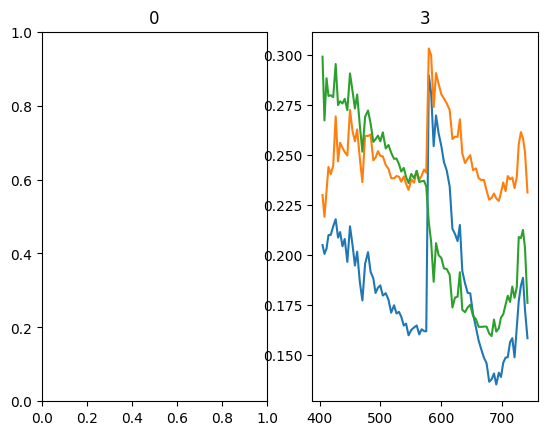

In [1]:
from custom_tools.acs_data_reader import get_acs_IOP
from custom_tools.acs_outlier_detection_functions import get_outlier_iterative_mask

import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"
f = "run_21_ACS.491"

df_arr_A, df_arr_C = get_acs_IOP(os.path.join(dir_path, f))
wav_A = np.array(df_arr_A.columns[1:].astype(float))
wav_C = np.array(df_arr_C.columns[1:].astype(float))

iter_outlier_mask_A = get_outlier_iterative_mask(df_arr_A.values[:, 1:], threshold=10)
outlier_df_A = df_arr_A[iter_outlier_mask_A]

iter_outlier_mask_C = get_outlier_iterative_mask(df_arr_C.values[:, 1:], threshold=10)
outlier_df_C = df_arr_C[iter_outlier_mask_C]

fig, ax = plt.subplots(ncols=2)

for i, outlier in outlier_df_A.iterrows():
    ax[0].plot(wav_A, outlier[1:])
for i, outlier in outlier_df_C.iterrows():
    ax[1].plot(wav_C, outlier[1:])

ax[0].set_title(len(outlier_df_A))
ax[1].set_title(len(outlier_df_C))